In [1]:
import numpy as np

In [2]:
class UnSupportedFileType(Exception):
    pass

In [3]:
def load_png_from_path(image_path):
    from os import PathLike
    from PIL import Image

    if not isinstance(image_path, (str, bytes, PathLike)):
        raise TypeError("image_path must be a filesystem path")
    
    try:
        with Image.open(image_path) as image:
            if image.format != "PNG":
                raise UnSupportedFileType(
                    f"Unsupported file type: {image.format or 'unknown'}"
                )
            
            image.load()
            if image.width < 1 or image.height < 1:
                raise ValueError("Image dimensions must be greater than zero")

            image_array = np.array(image.convert("RGB"), dtype=np.uint8, copy=True)
            if image_array.ndim != 3 or image_array.shape[2] != 3:
                raise ValueError("Decoded image must have three colour channels")
            
            return image_array
        
    except UnSupportedFileType:
        raise
    
    except (OSError, ValueError) as error:
        raise ValueError("Unreadable or corrupted PNG image") from error


In [4]:
def embed_image_payload(img_array, payload: bytes):
    if not isinstance(img_array, np.ndarray):
        raise TypeError("img_array must be a numpy array")
    
    if img_array.dtype != np.uint8:
        raise TypeError("img_array must have dtype uint8")
    
    if not isinstance(payload, bytes):
        raise TypeError("payload must be bytes")

    payload_bits = np.unpackbits(np.frombuffer(payload, dtype=np.uint8))
    flat_img = img_array.flatten()
    if payload_bits.size > flat_img.size:
        raise ValueError("payload is too large for the image capacity")

    flat_img[:payload_bits.size] &= np.uint8(0xFE)
    flat_img[:payload_bits.size] |= payload_bits
    return flat_img.reshape(img_array.shape)

Loaded: Banana.png
Saved: LSB-Banana.png
Payload: 'BANANA!!' -> 0100001001000001010011100100000101001110010000010010000100100001
Shape: (1568, 1280, 3); payload: 8 bytes


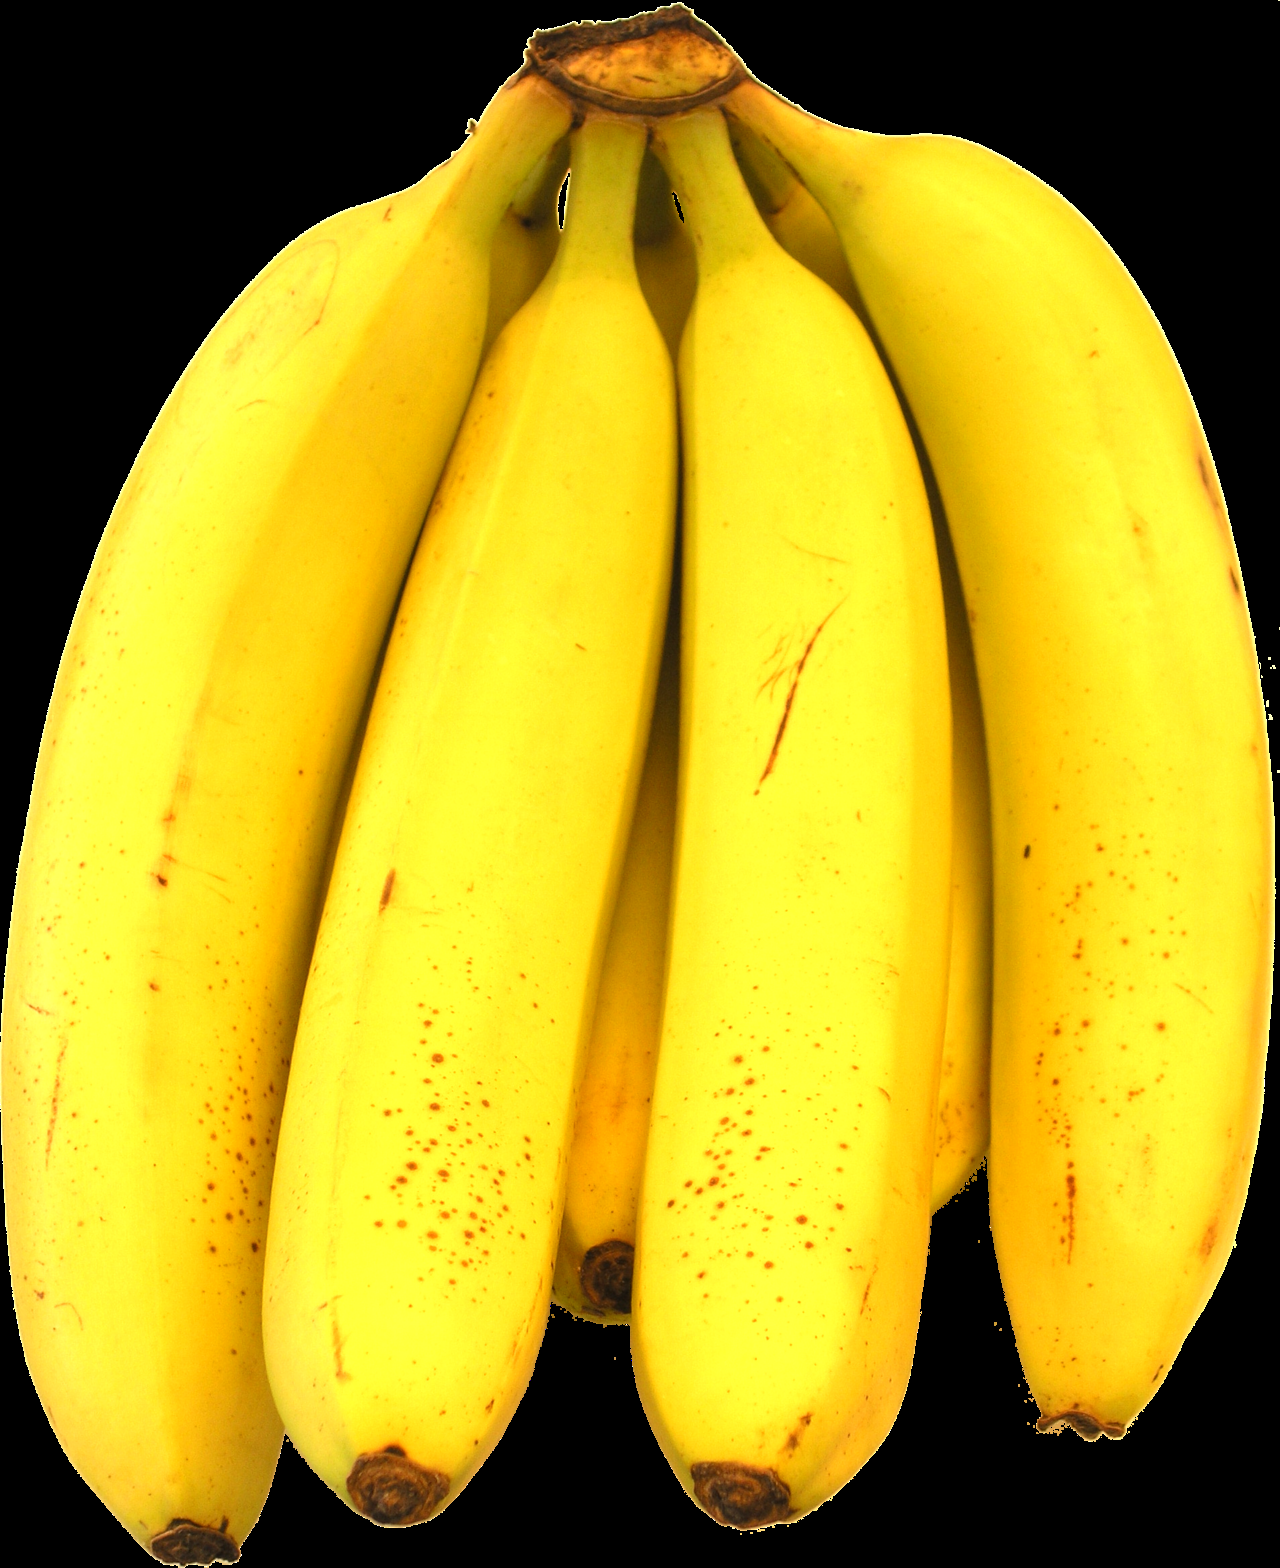

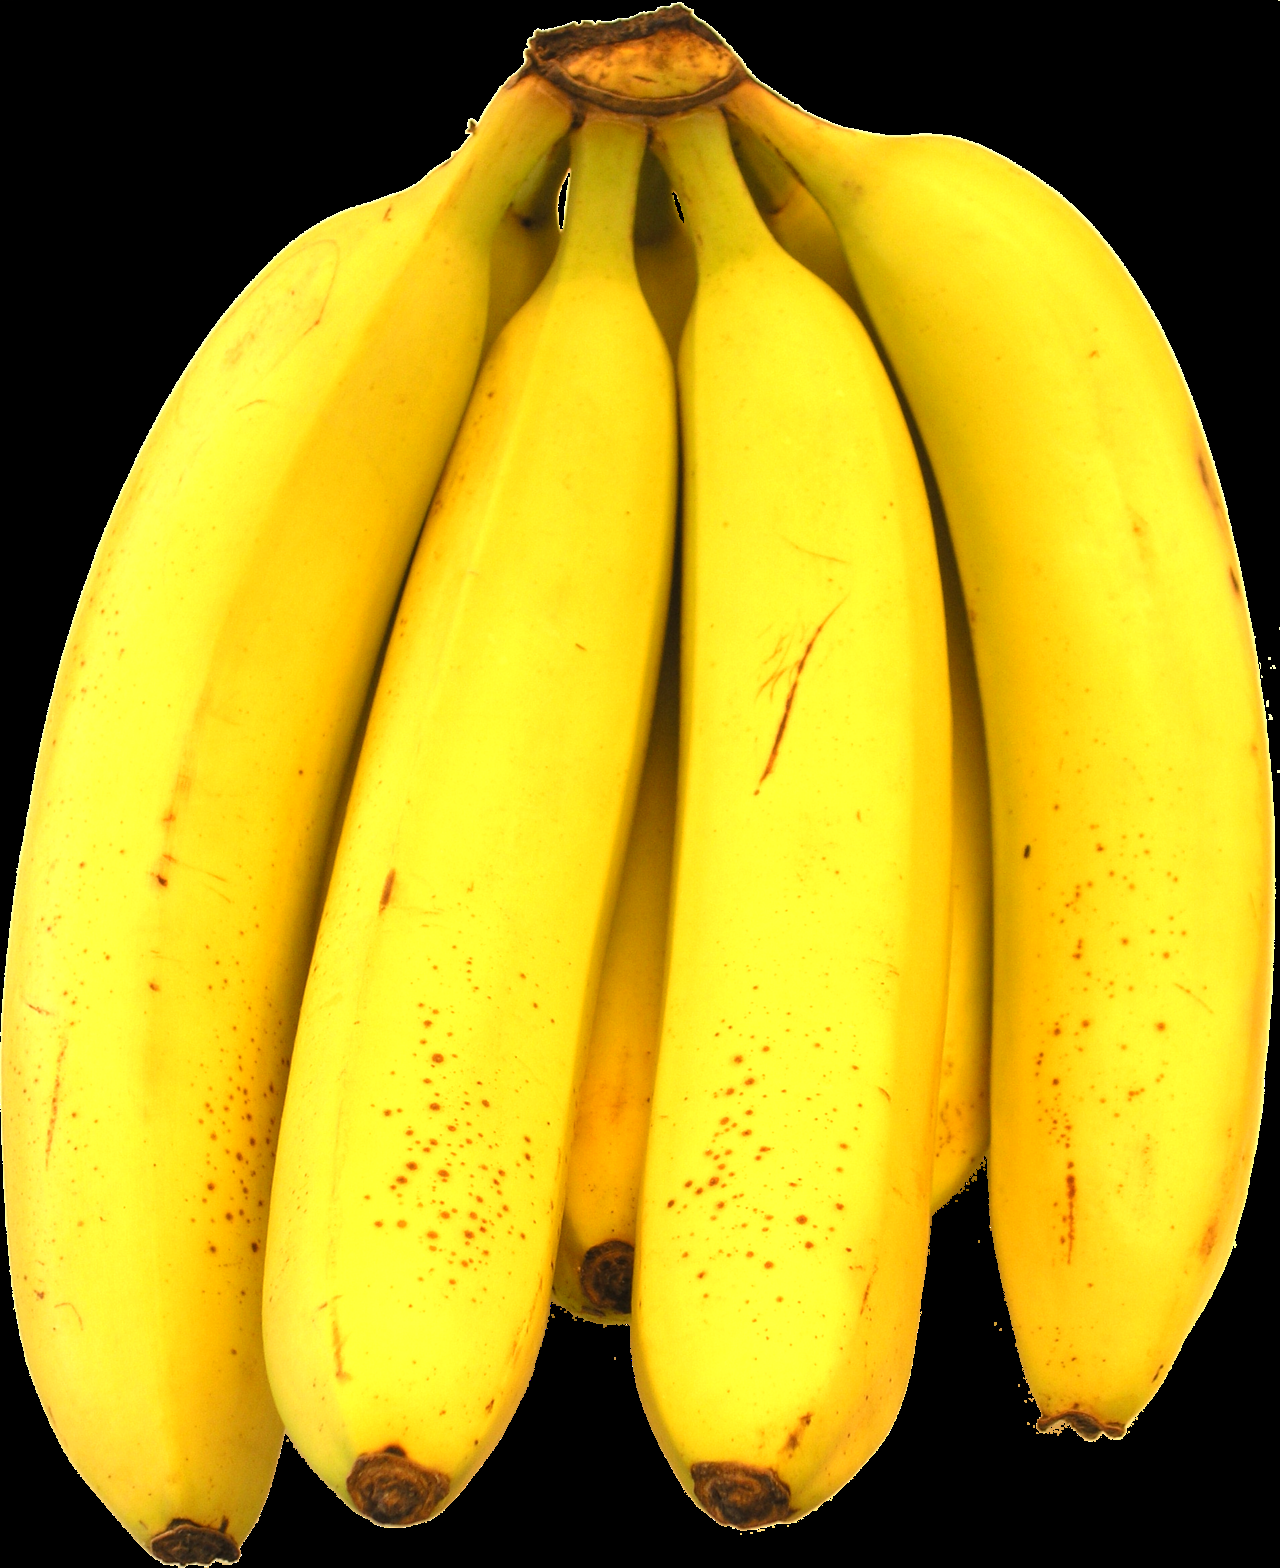

In [5]:
from pathlib import Path
from IPython.display import display
from PIL import Image

image_path = Path("Banana.png")
if not image_path.exists():
    image_path = Path("notebooks") / "Banana.png"

def ascii_to_binary(message: str) -> str:
    if not isinstance(message, str):
        raise TypeError("message must be a string")
    try:
        return "".join(f"{byte:08b}" for byte in message.encode("ascii"))
    except UnicodeEncodeError as error:
        raise ValueError("message must contain ASCII characters") from error

message = "BANANA!!"
payload = message.encode("ascii")
payload_binary = ascii_to_binary(message)
original_image_array = load_png_from_path(image_path)
stego_image_array = embed_image_payload(original_image_array, payload)

payload_bits = np.unpackbits(np.frombuffer(payload, dtype=np.uint8))
assert original_image_array.shape == stego_image_array.shape
assert original_image_array.dtype == stego_image_array.dtype == np.uint8
assert np.array_equal(original_image_array, load_png_from_path(image_path))
assert np.array_equal(
    stego_image_array.reshape(-1)[:payload_bits.size] & 1,
    payload_bits,
)

original_image = Image.fromarray(original_image_array)
stego_image = Image.fromarray(stego_image_array)
output_path = image_path.with_name("LSB-Banana.png")
stego_image.save(output_path, format="PNG")
print(f"Loaded: {image_path}")
print(f"Saved: {output_path}")
print(f"Payload: {message!r} -> {payload_binary}")
print(f"Shape: {original_image_array.shape}; payload: {len(payload)} bytes")
display(original_image)
display(stego_image)
